# Machine Learning Notebook

Starter notebook for experiments and prototyping.

In [ ]:
# System Libs
import os

# Data Libs
import kagglehub
import numpy as np
import pandas as pd

# Graphs Libs
import seaborn as sns
import matplotlib.pyplot as plt

# SkLearn
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

/home/josej/miniconda3/envs/ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Download the Dataset
path = kagglehub.dataset_download("rhythmghai/250k-job-salary-prediction-dataset")
csv_path = f"{path}/{os.listdir(path)[0]}"
df = pd.read_csv(csv_path)

In [3]:
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


### Stage 1: Data Cleanup

#### Resolve Ambiguous Columns

In [4]:
# Duplicate feature rows with different salaries
feature_cols = [col for col in df.columns if col != "salary"]

duplicate_feature_rows = (
    df[df.duplicated(subset=feature_cols, keep=False)]
    .sort_values(feature_cols + ["salary"])
    .reset_index(drop=True)
)

print("Rows involved in duplicate feature combinations:", len(duplicate_feature_rows))
print("Unique duplicate feature combinations:", duplicate_feature_rows[feature_cols].drop_duplicates().shape[0])

display(duplicate_feature_rows)

duplicate_summary = (
    duplicate_feature_rows
    .groupby(feature_cols, as_index=False)["salary"]
    .agg(["count", "nunique", "min", "max", "mean"])
    .reset_index()
    .sort_values(["nunique", "count", "max"], ascending=[False, False, False])
)

# display(duplicate_summary.head(20))


Rows involved in duplicate feature combinations: 280
Unique duplicate feature combinations: 140


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,2,High School,9,Technology,Small,Singapore,No,1,113490
1,AI Engineer,2,High School,9,Technology,Small,Singapore,No,1,118820
2,AI Engineer,3,PhD,9,Finance,Small,Australia,No,3,149515
3,AI Engineer,3,PhD,9,Finance,Small,Australia,No,3,158530
4,AI Engineer,4,Diploma,4,Retail,Enterprise,Canada,No,3,198239
...,...,...,...,...,...,...,...,...,...,...
275,Software Engineer,16,Master,19,Manufacturing,Large,USA,Yes,1,234919
276,Software Engineer,18,High School,10,Government,Large,Germany,Yes,4,171319
277,Software Engineer,18,High School,10,Government,Large,Germany,Yes,4,179600
278,Software Engineer,19,Master,19,Consulting,Startup,Sweden,Hybrid,3,145818


In [5]:
# Duplicate feature rows with salary spread over $20,000
feature_cols = [col for col in df.columns if col != "salary"]

duplicate_salary_spread = (
    df[df.duplicated(subset=feature_cols, keep=False)]
    .groupby(feature_cols, as_index=False)["salary"]
    .agg(["count", "nunique", "min", "max", "mean"])
    .reset_index()
)

duplicate_salary_spread["salary_diff"] = duplicate_salary_spread["max"] - duplicate_salary_spread["min"]
large_spread_duplicates = duplicate_salary_spread[duplicate_salary_spread["salary_diff"] > 15000].sort_values("salary_diff", ascending=False)

print("Duplicate groups with salary diff > $20,000:", len(large_spread_duplicates))
display(large_spread_duplicates)


Duplicate groups with salary diff > $20,000: 5


,index,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,count,nunique,min,max,mean,salary_diff
16,16,AI Engineer,18,Bachelor,10,Technology,Medium,Remote,Hybrid,5,2,2,173439,192707,183073.0,19268
45,45,Business Analyst,17,Diploma,1,Education,Startup,Remote,No,2,2,2,88792,106661,97726.5,17869
126,126,Product Manager,16,Bachelor,13,Media,Medium,Canada,Yes,3,2,2,185549,202270,193909.5,16721
85,85,DevOps Engineer,8,Bachelor,14,Education,Medium,Germany,Hybrid,5,2,2,144144,159950,152047.0,15806
84,84,DevOps Engineer,5,PhD,15,Finance,Small,Germany,Yes,3,2,2,151036,166761,158898.5,15725


In [6]:
# Average duplicate feature rows to reduce negotiation noise
feature_cols = [col for col in df.columns if col != "salary"]

df_model = (
    df.groupby(feature_cols, as_index=False)["salary"]
    .mean()
)

print("Original shape:", df.shape)
print("Collapsed shape:", df_model.shape)
print("Rows removed:", len(df) - len(df_model))

df_model.sample(10)


Original shape: (250000, 10)
Collapsed shape: (249860, 10)
Rows removed: 140


,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
192549,Machine Learning Engineer,5,Bachelor,14,Retail,Enterprise,India,Yes,3,120432.0
121874,Data Analyst,17,PhD,2,Manufacturing,Small,UK,Yes,4,155344.0
88477,Cybersecurity Analyst,5,Bachelor,12,Retail,Small,India,Yes,3,91586.0
58949,Business Analyst,17,Diploma,8,Manufacturing,Enterprise,Canada,No,5,177109.0
41977,Backend Developer,20,PhD,15,Finance,Enterprise,Sweden,Hybrid,1,196587.0
111668,Data Analyst,7,High School,4,Technology,Startup,UK,Yes,5,101642.0
49526,Business Analyst,7,Master,10,Manufacturing,Small,Canada,Hybrid,3,127666.0
103271,Cybersecurity Analyst,19,PhD,15,Healthcare,Enterprise,Remote,No,5,221243.0
130870,Data Scientist,6,Bachelor,5,Education,Medium,Australia,No,5,126555.0
33952,Backend Developer,12,PhD,12,Government,Small,Remote,Yes,0,141613.0


#### Normalize ambiguous location values

In [7]:
df_model_clean = df_model.copy()

remote_location_rows = (df_model_clean["location"] == "Remote").sum()
print("Rows with location='Remote' before cleanup:", remote_location_rows)

df_model_clean["location"] = df_model_clean["location"].replace("Remote", "Unknown")

print("Rows with location='Remote' after cleanup:", (df_model_clean["location"] == "Remote").sum())
print("Rows with location='Unknown' after cleanup:", (df_model_clean["location"] == "Unknown").sum())

Rows with location='Remote' before cleanup: 25051
Rows with location='Remote' after cleanup: 0
Rows with location='Unknown' after cleanup: 25051


#### Declare Categorical Features

In [8]:
categorical_cols = [
    "job_title",
    "education_level",
    "company_size",
    "location",
    "remote_work",
]

for col in categorical_cols:
    df_model_clean[col] = df_model_clean[col].astype("category")

df_model_clean.dtypes


job_title           category
experience_years       int64
education_level     category
skills_count           int64
industry                 str
company_size        category
location            category
remote_work         category
certifications         int64
salary               float64
dtype: object

#### Drop Weak Feature: Industry


In [9]:
df_model_final = df_model_clean.drop(columns=["industry"]).copy()

print("Dropped columns:", ["industry"])
print("Remaining columns:")
print(df_model_final.columns.tolist())


Dropped columns: ['industry']
Remaining columns:
['job_title', 'experience_years', 'education_level', 'skills_count', 'company_size', 'location', 'remote_work', 'certifications', 'salary']


### See Correlation Matrix (for feature engineering)

,experience_years,skills_count,certifications,salary
experience_years,1.000000,0.000145,-0.000255,0.437646
skills_count,0.000145,1.000000,-0.002227,0.127206
certifications,-0.000255,-0.002227,1.000000,0.073840
salary,0.437646,0.127206,0.073840,1.000000


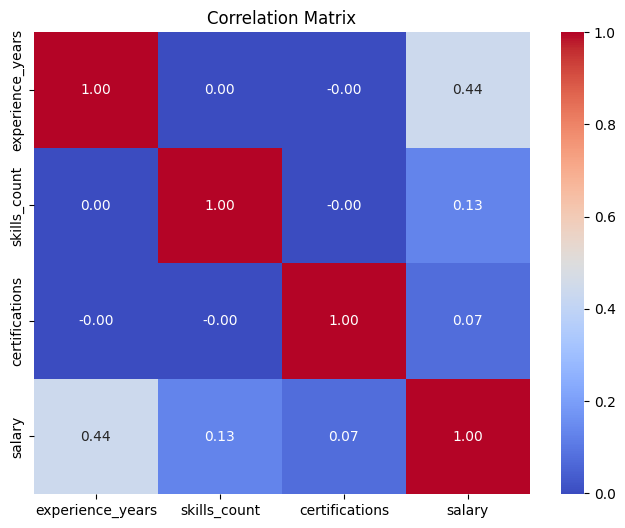

salary              1.000000
experience_years    0.437646
skills_count        0.127206
certifications      0.073840
Name: salary, dtype: float64


In [10]:
numeric_df = df_model_final.select_dtypes(include=["int64", "float64"])
corr = numeric_df.corr()

display(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

print(corr["salary"].sort_values(ascending=False))


### Stage 2: Modelling

### Define Features and Target


In [11]:
target = "salary"

categorical_features = [
    "job_title",
    "education_level",
    "company_size",
    "location",
    "remote_work",
]

numeric_features = [
    "experience_years",
    "skills_count",
    "certifications",
]

feature_cols = categorical_features + numeric_features

X = df_model_final[feature_cols].copy()
y = df_model_final[target].copy()

print("Feature columns:", feature_cols)
print("X shape:", X.shape)
print("y shape:", y.shape)


Feature columns: ['job_title', 'education_level', 'company_size', 'location', 'remote_work', 'experience_years', 'skills_count', 'certifications']
X shape: (249860, 8)
y shape: (249860,)


### Preprocess and Split Data


In [12]:


preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (199888, 8)
X_test shape: (49972, 8)
y_train shape: (199888,)
y_test shape: (49972,)


### Train Baseline Models


In [13]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
}

results = []
fitted_models = {}

for name, regressor in models.items():
    model = Pipeline([
        ("preprocessor", preprocessor),
        ("regressor", regressor),
    ])

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    })

    fitted_models[name] = {
        "pipeline": model,
        "predictions": preds,
    }

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)


,model,MAE,RMSE,R2
1,RandomForestRegressor,4876.350230,6145.231784,0.972937
0,LinearRegression,5465.570504,7148.133520,0.963382


### Inspect Best Baseline Predictions


In [14]:
best_model_name = results_df.iloc[0]["model"]
best_preds = fitted_models[best_model_name]["predictions"]

comparison_df = X_test.copy()
comparison_df["actual_salary"] = y_test.values
comparison_df["predicted_salary"] = best_preds
comparison_df["error"] = comparison_df["predicted_salary"] - comparison_df["actual_salary"]

print("Best model:", best_model_name)
display(comparison_df[["actual_salary", "predicted_salary", "error"]].head(10))


Best model: RandomForestRegressor


,actual_salary,predicted_salary,error
169278,102468.0,105410.270,2942.270
77800,178434.0,175902.195,-2531.805
97655,115618.0,128239.340,12621.340
158221,125130.0,126347.285,1217.285
117,163497.0,171119.780,7622.780
155784,149588.0,158559.590,8971.590
201792,142927.0,150055.725,7128.725
112160,117821.0,120410.125,2589.125
121060,202592.0,209131.160,6539.160
73939,159345.0,166247.045,6902.045


### Feature Importance


In [15]:
best_pipeline = fitted_models["RandomForestRegressor"]["pipeline"]
rf_model = best_pipeline.named_steps["regressor"]
preprocessor_fitted = best_pipeline.named_steps["preprocessor"]

feature_names = preprocessor_fitted.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances,
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(feature_importance_df.head(20))


,feature,importance
0,num__experience_years,0.198622
1,cat__location_India,0.181570
2,cat__company_size_Enterprise,0.104037
3,cat__location_USA,0.077088
4,cat__education_level_PhD,0.060875
5,cat__job_title_AI Engineer,0.052514
6,cat__company_size_Large,0.049607
7,cat__job_title_Data Analyst,0.036590
8,cat__job_title_Business Analyst,0.035164
9,cat__location_Canada,0.033980


### Aggregated Feature Importance


In [16]:
# Rebuild feature_importance_df if this cell is run after a kernel restart
if "feature_importance_df" not in globals():
    best_pipeline = fitted_models["RandomForestRegressor"]["pipeline"]
    rf_model = best_pipeline.named_steps["regressor"]
    preprocessor_fitted = best_pipeline.named_steps["preprocessor"]
    feature_names = preprocessor_fitted.get_feature_names_out()
    importances = rf_model.feature_importances_
    feature_importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": importances,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

def map_feature_group(feature_name):
    if feature_name.startswith("cat__job_title_"):
        return "job_title"
    if feature_name.startswith("cat__education_level_"):
        return "education_level"
    if feature_name.startswith("cat__company_size_"):
        return "company_size"
    if feature_name.startswith("cat__location_"):
        return "location"
    if feature_name.startswith("cat__remote_work_"):
        return "remote_work"
    if feature_name == "num__experience_years":
        return "experience_years"
    if feature_name == "num__skills_count":
        return "skills_count"
    if feature_name == "num__certifications":
        return "certifications"
    return feature_name

grouped_importance_df = feature_importance_df.copy()
grouped_importance_df["feature_group"] = grouped_importance_df["feature"].apply(map_feature_group)

grouped_importance_df = (
    grouped_importance_df.groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(grouped_importance_df)


,feature_group,importance
0,location,0.328777
1,experience_years,0.198622
2,company_size,0.168756
3,job_title,0.166657
4,education_level,0.098705
5,skills_count,0.023234
6,certifications,0.009007
7,remote_work,0.006243


### Compare Stronger Models


In [17]:


# Linear and bagged tree models use one-hot encoding.
preprocessor_onehot = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

# Boosted sklearn/XGBoost/LightGBM models use dense ordinal-coded categories.
preprocessor_ordinal = ColumnTransformer(
    transformers=[
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), categorical_features),
        ("num", "passthrough", numeric_features),
    ]
)

model_specs = [
    ("LinearRegression", preprocessor_onehot, LinearRegression()),
    ("RandomForestRegressor", preprocessor_onehot, RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
    ("ExtraTreesRegressor", preprocessor_onehot, ExtraTreesRegressor(n_estimators=300, random_state=42, n_jobs=-1)),
    ("HistGradientBoostingRegressor", preprocessor_ordinal, HistGradientBoostingRegressor(random_state=42)),
    ("XGBRegressor", preprocessor_ordinal, XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9, objective="reg:squarederror", random_state=42, n_jobs=-1)),
    ("LGBMRegressor", preprocessor_ordinal, LGBMRegressor(n_estimators=400, learning_rate=0.05, random_state=42, verbose=-1)),
]

results = []
benchmark_models = {}

for name, current_preprocessor, regressor in model_specs:
    model = Pipeline([
        ("preprocessor", current_preprocessor),
        ("regressor", regressor),
    ])
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results.append({
        "model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
    })
    benchmark_models[name] = {"pipeline": model, "predictions": preds}

# CatBoost handles categorical features directly.
catboost_X_train = X_train.copy()
catboost_X_test = X_test.copy()
for col in categorical_features:
    catboost_X_train[col] = catboost_X_train[col].astype(str)
    catboost_X_test[col] = catboost_X_test[col].astype(str)

catboost_model = CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, loss_function="RMSE", eval_metric="RMSE", random_state=42, verbose=False)
catboost_model.fit(catboost_X_train, y_train, cat_features=categorical_features)
catboost_preds = catboost_model.predict(catboost_X_test)
results.append({
    "model": "CatBoostRegressor",
    "MAE": mean_absolute_error(y_test, catboost_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, catboost_preds)),
    "R2": r2_score(y_test, catboost_preds),
})
benchmark_models["CatBoostRegressor"] = {"pipeline": catboost_model, "predictions": catboost_preds}

results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
display(results_df)


/home/josej/miniconda3/envs/ml/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,model,MAE,RMSE,R2
0,CatBoostRegressor,4025.291128,5050.937361,0.981717
1,XGBRegressor,4155.178243,5208.569637,0.980558
2,LGBMRegressor,4155.238463,5213.255781,0.980523
3,HistGradientBoostingRegressor,4549.856112,5707.240123,0.976657
4,RandomForestRegressor,4876.350230,6145.231784,0.972937
5,ExtraTreesRegressor,5020.723482,6314.697486,0.971423
6,LinearRegression,5465.570504,7148.133520,0.963382


### Selected Final Model


In [18]:
benchmark_winner_name = results_df.iloc[0]["model"]
print("Selected benchmark winner:", benchmark_winner_name)

if benchmark_winner_name != "CatBoostRegressor":
    print("Warning: current best model is not CatBoostRegressor. Check the benchmark results.")

final_model_name = "CatBoostRegressor"
final_model = benchmark_models[final_model_name]["pipeline"]
final_predictions = benchmark_models[final_model_name]["predictions"]

print("Using untuned CatBoost as the interim final model until the tuning section below is run.")

final_metrics = results_df[results_df["model"] == final_model_name].reset_index(drop=True)
display(final_metrics)


Selected benchmark winner: CatBoostRegressor
Using untuned CatBoost as the interim final model until the tuning section below is run.


,model,MAE,RMSE,R2
0,CatBoostRegressor,4025.291128,5050.937361,0.981717


### CatBoost Feature Importance


In [19]:
catboost_feature_importance_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance": final_model.get_feature_importance(),
}).sort_values("importance", ascending=False).reset_index(drop=True)

display(catboost_feature_importance_df)


,feature,importance
0,location,28.870860
1,experience_years,21.308593
2,company_size,18.847162
3,job_title,17.559612
4,education_level,10.439752
5,skills_count,1.799238
6,certifications,0.630982
7,remote_work,0.543801


### Predict Salary for One Person


In [20]:
# Edit this profile to estimate salary for a new person.
person_profile = pd.DataFrame([
    {
        "job_title": "Data Scientist",
        "education_level": "Master",
        "company_size": "Large",
        "location": "Canada",
        "remote_work": "Hybrid",
        "experience_years": 6,
        "skills_count": 12,
        "certifications": 2,
    }
])

predicted_salary = final_model.predict(person_profile)[0]
print("Predicted salary: ${:,.2f}".format(predicted_salary))
display(person_profile)


Predicted salary: $175,427.18


,job_title,education_level,company_size,location,remote_work,experience_years,skills_count,certifications
0,Data Scientist,Master,Large,Canada,Hybrid,6,12,2


### Tune CatBoost Hyperparameters


In [21]:
from itertools import product
from sklearn.model_selection import train_test_split

X_train_cb = X_train.copy()
X_test_cb = X_test.copy()
for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

X_train_inner, X_valid, y_train_inner, y_valid = train_test_split(
    X_train_cb, y_train, test_size=0.2, random_state=42
)

param_grid = {
    "depth": [4, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "iterations": [300, 500, 800],
    "l2_leaf_reg": [1, 3, 5, 7],
}

tuning_results = []
best_catboost_model = None
best_rmse = float("inf")
best_params = None

for depth, learning_rate, iterations, l2_leaf_reg in product(
    param_grid["depth"],
    param_grid["learning_rate"],
    param_grid["iterations"],
    param_grid["l2_leaf_reg"],
):
    candidate_model = CatBoostRegressor(
        depth=depth,
        learning_rate=learning_rate,
        iterations=iterations,
        l2_leaf_reg=l2_leaf_reg,
        loss_function="RMSE",
        eval_metric="RMSE",
        random_state=42,
        verbose=False,
    )
    candidate_model.fit(
        X_train_inner, y_train_inner,
        cat_features=categorical_features,
    )
    valid_preds = candidate_model.predict(X_valid)
    valid_rmse = np.sqrt(mean_squared_error(y_valid, valid_preds))
    valid_mae = mean_absolute_error(y_valid, valid_preds)
    tuning_results.append({
        "depth": depth,
        "learning_rate": learning_rate,
        "iterations": iterations,
        "l2_leaf_reg": l2_leaf_reg,
        "valid_MAE": valid_mae,
        "valid_RMSE": valid_rmse,
    })
    if valid_rmse < best_rmse:
        best_rmse = valid_rmse
        best_params = {
            "depth": depth,
            "learning_rate": learning_rate,
            "iterations": iterations,
            "l2_leaf_reg": l2_leaf_reg,
        }

tuning_results_df = pd.DataFrame(tuning_results).sort_values("valid_RMSE").reset_index(drop=True)
display(tuning_results_df.head(10))
print("Best params:", best_params)


,depth,learning_rate,iterations,l2_leaf_reg,valid_MAE,valid_RMSE
0,8,0.05,800,1,3999.725166,5015.363161
1,6,0.10,800,1,4001.311764,5017.827888
2,6,0.10,800,3,4001.529578,5018.073675
3,8,0.10,800,7,4002.581598,5018.425278
4,6,0.10,800,7,4001.719150,5018.978428
5,8,0.10,800,5,4003.378930,5019.071453
6,8,0.05,800,5,4003.628021,5019.171145
7,8,0.10,500,3,4002.844633,5019.405148
8,8,0.10,500,7,4002.897067,5019.436944
9,8,0.10,500,5,4003.696785,5019.617207


Best params: {'depth': 8, 'learning_rate': 0.05, 'iterations': 800, 'l2_leaf_reg': 1}


### Train Tuned CatBoost and Compare


In [22]:
tuned_catboost_model = CatBoostRegressor(
    depth=best_params["depth"],
    learning_rate=best_params["learning_rate"],
    iterations=best_params["iterations"],
    l2_leaf_reg=best_params["l2_leaf_reg"],
    loss_function="RMSE",
    eval_metric="RMSE",
    random_state=42,
    verbose=False,
)

tuned_catboost_model.fit(X_train_cb, y_train, cat_features=categorical_features)
tuned_catboost_preds = tuned_catboost_model.predict(X_test_cb)

untuned_metrics = results_df[results_df["model"] == "CatBoostRegressor"].copy()
untuned_metrics["model"] = "CatBoostRegressor_Untuned"

tuned_metrics = pd.DataFrame([{
    "model": "CatBoostRegressor_Tuned",
    "MAE": mean_absolute_error(y_test, tuned_catboost_preds),
    "RMSE": np.sqrt(mean_squared_error(y_test, tuned_catboost_preds)),
    "R2": r2_score(y_test, tuned_catboost_preds),
}])

display(pd.concat([untuned_metrics, tuned_metrics], ignore_index=True))


,model,MAE,RMSE,R2
0,CatBoostRegressor_Untuned,4025.291128,5050.937361,0.981717
1,CatBoostRegressor_Tuned,3998.003114,5017.668288,0.981957


### Promote Tuned CatBoost to Final Model


In [23]:
final_model_name = "CatBoostRegressor_Tuned"
final_model = tuned_catboost_model
final_predictions = tuned_catboost_preds
final_metrics = tuned_metrics.copy()

print("Selected final model:", final_model_name)
display(final_metrics)


Selected final model: CatBoostRegressor_Tuned


,model,MAE,RMSE,R2
0,CatBoostRegressor_Tuned,3998.003114,5017.668288,0.981957


### Cross-Validate Tuned Final Model


In [24]:
from sklearn.model_selection import KFold

X_cv = X.copy()
for col in categorical_features:
    X_cv[col] = X_cv[col].astype(str)

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for fold, (train_idx, valid_idx) in enumerate(cv.split(X_cv), start=1):
    X_fold_train = X_cv.iloc[train_idx].copy()
    X_fold_valid = X_cv.iloc[valid_idx].copy()
    y_fold_train = y.iloc[train_idx]
    y_fold_valid = y.iloc[valid_idx]

    cv_model = CatBoostRegressor(
        depth=best_params["depth"],
        learning_rate=best_params["learning_rate"],
        iterations=best_params["iterations"],
        l2_leaf_reg=best_params["l2_leaf_reg"],
        loss_function="RMSE",
        eval_metric="RMSE",
        random_state=42,
        verbose=False,
    )

    cv_model.fit(X_fold_train, y_fold_train, cat_features=categorical_features)
    cv_preds = cv_model.predict(X_fold_valid)

    cv_results.append({
        "fold": fold,
        "MAE": mean_absolute_error(y_fold_valid, cv_preds),
        "RMSE": np.sqrt(mean_squared_error(y_fold_valid, cv_preds)),
        "R2": r2_score(y_fold_valid, cv_preds),
    })

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

cv_summary_df = pd.DataFrame([
    {
        "model": final_model_name,
        "MAE_mean": cv_results_df["MAE"].mean(),
        "MAE_std": cv_results_df["MAE"].std(ddof=1),
        "RMSE_mean": cv_results_df["RMSE"].mean(),
        "RMSE_std": cv_results_df["RMSE"].std(ddof=1),
        "R2_mean": cv_results_df["R2"].mean(),
        "R2_std": cv_results_df["R2"].std(ddof=1),
    }
])

display(cv_summary_df)


,fold,MAE,RMSE,R2
0,1,3996.392398,5014.617803,0.981979
1,2,4016.901106,5029.463231,0.982033
2,3,4010.429879,5030.535733,0.981929
3,4,4002.233144,5015.140566,0.981914
4,5,4005.340901,5019.529868,0.982020


,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,CatBoostRegressor_Tuned,4006.259486,7.827051,5021.85744,7.682889,0.981975,0.000053


In [25]:
display(cv_summary_df)

,model,MAE_mean,MAE_std,RMSE_mean,RMSE_std,R2_mean,R2_std
0,CatBoostRegressor_Tuned,4006.259486,7.827051,5021.85744,7.682889,0.981975,0.000053


### Export Final Model for AppHosting

Run this after the final model and cross-validation cells to export the deployable model artifacts into `../AppHosting/model_artifacts/`.


In [27]:
from pathlib import Path
import json

app_hosting_dir = Path.cwd().resolve().parent / "AppHosting" / "model_artifacts"
app_hosting_dir.mkdir(parents=True, exist_ok=True)

model_export_path = app_hosting_dir / "salary_model.cbm"
metadata_export_path = app_hosting_dir / "metadata.json"

final_model.save_model(model_export_path)

category_options = {
    column: sorted(df_model_final[column].astype(str).unique().tolist())
    for column in categorical_features
}

export_metadata = {
    "model_name": final_model_name,
    "feature_columns": feature_cols,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "target_column": target,
    "category_options": category_options,
    "holdout_metrics": final_metrics.iloc[0].to_dict(),
    "cross_validation_summary": cv_summary_df.iloc[0].to_dict(),
}

metadata_export_path.write_text(json.dumps(export_metadata, indent=2), encoding="utf-8")

print(f"Exported model to: {model_export_path}")
print(f"Exported metadata to: {metadata_export_path}")
display(pd.DataFrame([export_metadata["holdout_metrics"]]))
display(pd.Series({k: len(v) for k, v in category_options.items()}, name="options_count"))


Exported model to: /home/josej/Projects/SalaryPredictions/AppHosting/model_artifacts/salary_model.cbm
Exported metadata to: /home/josej/Projects/SalaryPredictions/AppHosting/model_artifacts/metadata.json


,model,MAE,RMSE,R2
0,CatBoostRegressor_Tuned,3998.003114,5017.668288,0.981957


job_title          12
education_level     5
company_size        5
location           10
remote_work         3
Name: options_count, dtype: int64

In [29]:
export_metadata['category_options']['job_title']

['AI Engineer',
 'Backend Developer',
 'Business Analyst',
 'Cloud Engineer',
 'Cybersecurity Analyst',
 'Data Analyst',
 'Data Scientist',
 'DevOps Engineer',
 'Frontend Developer',
 'Machine Learning Engineer',
 'Product Manager',
 'Software Engineer']